In [8]:
from modeller import *

env = Environ()
aln = Alignment(env)

# Template 1
mdl = Model(env, file='../pde4d_swissmodel', model_segment=('FIRST:A','LAST:A'))
aln.append_model(mdl, align_codes='pde4d_swissmodel', atom_files='../pde4d_swissmodel.pdb')

# Template 2
mdl2 = Model(env, file='../3G45', model_segment=('247:A','658:A'))
aln.append_model(mdl2, align_codes='pde4b_3g45', atom_files='../3G45.pdb')

# Alinha as duas estruturas entre si
aln.salign()

# Adiciona a sequência completa do alvo
aln.append(file='../pde4b_target.ali', align_codes='pde4b_target')

# Alinha a sequência ao alinhamento estrutural
aln.align2d(max_gap_length=50)

aln.write(file='pde4d-pde4b.ali', alignment_format='PIR')
aln.write(file='pde4d-pde4b.pap', alignment_format='PAP')

readlinef__W> File: ../3G45.pdb, Line: 5
              Modeller will only read the first 80 characters of this line.


SALIGN_____> adding the next group to the alignment; iteration    1
mkapsa__637W> No residue topology library is in memory.
              Better radii would be used if topology.read() is called first.
iup2crm_280W> No topology library in memory or assigning a BLK residue.
              Default CHARMM atom type assigned:  N -->  N
              This message is written only for the first such atom.

Pairwise dynamic programming alignment (ALIGN2D):
  Residue-residue metric   : $(LIB)/as1.sim.mat
  Diagonal                 :          100
  Overhang                 :            0
  Maximal gap length       :           50
  Local alignment          :            F
  MATRIX_OFFSET (local aln):       0.0000
  FIX_OFFSETS              :      0.0    -1.0    -2.0    -3.0    -4.0
  N_SUBOPT                 :            0
  SUBOPT_OFFSET            :       0.0000
  Alignment block 

In [3]:
from modeller import *
from modeller.automodel import *

env = Environ()
env.rand_seed = -1

a = AutoModel(env,
              alnfile='pde4d-pde4b.ali',
              knowns=('pde4d_swissmodel', 'pde4b_3g45'),
              sequence='pde4b_target',
              assess_methods=assess.DOPE)

a.template_weights = (0.4, 1.0)

a.starting_model = 1
a.ending_model = 10

a.make()

openf___224_> Open           $(LIB)/restyp.lib
openf___224_> Open           ${MODINSTALL10v7}/modlib/restyp_cif.lib
openf___224_> Open           ${MODINSTALL10v7}/modlib/resgrp.lib
rdresgr_266_> Number of residue groups:        2
openf___224_> Open           ${MODINSTALL10v7}/modlib/sstruc.lib

Dynamically allocated memory at   amaxlibraries [B,KiB,MiB]:       628888     614.148     0.600

Dynamically allocated memory at   amaxlibraries [B,KiB,MiB]:       629416     614.664     0.600
openf___224_> Open           ${MODINSTALL10v7}/modlib/resdih.lib

Dynamically allocated memory at   amaxlibraries [B,KiB,MiB]:       678016     662.125     0.647
rdrdih__263_> Number of dihedral angle types         :        9
              Maximal number of dihedral angle optima:        3
              Dihedral angle names                   :  Alph Phi Psi Omeg chi1 chi2 chi3 chi4 chi5
openf___224_> Open           ${MODINSTALL10v7}/modlib/radii.lib

Dynamically allocated memory at   amaxlibraries [B,KiB,Mi

In [ ]:
from modeller import *
from modeller.scripts import complete_pdb
import glob
import os

log.verbose()
env = Environ()
env.libs.topology.read(file='$(LIB)/top_heav.lib')
env.libs.parameters.read(file='$(LIB)/par.lib')

#modelling_dir = '/home/gbiuser/Documents/vitoria/usp-masters/data/structure_prediction/homology_modelling/'
modelling_dir = r'C:\Users\vitor\Documents\usp\usp-masters\data\structure_prediction\homology_modelling'
model_files = sorted(glob.glob(os.path.join(modelling_dir, '*.B9999*.pdb')))

for i, model_path in enumerate(model_files, start=1):
    profile_file = os.path.join(modelling_dir, f'model{i}.profile')
    
    print(f'calc DOPE model {i}: {os.path.basename(model_path)}')
    
    mdl = complete_pdb(env, model_path)
    s = Selection(mdl)
    s.assess_dope(output='ENERGY_PROFILE NO_REPORT', file=profile_file,
                  normalize_profile=True, smoothing_window=15)


openf___224_> Open           $(LIB)/restyp.lib
openf___224_> Open           ${MODINSTALL10v7}/modlib/restyp_cif.lib
openf___224_> Open           ${MODINSTALL10v7}/modlib/resgrp.lib
rdresgr_266_> Number of residue groups:        2
openf___224_> Open           ${MODINSTALL10v7}/modlib/sstruc.lib

Dynamically allocated memory at   amaxlibraries [B,KiB,MiB]:     23782598   23225.193    22.681

Dynamically allocated memory at   amaxlibraries [B,KiB,MiB]:     23783126   23225.709    22.681
openf___224_> Open           ${MODINSTALL10v7}/modlib/resdih.lib

Dynamically allocated memory at   amaxlibraries [B,KiB,MiB]:     23831726   23273.170    22.728
rdrdih__263_> Number of dihedral angle types         :        9
              Maximal number of dihedral angle optima:        3
              Dihedral angle names                   :  Alph Phi Psi Omeg chi1 chi2 chi3 chi4 chi5
openf___224_> Open           ${MODINSTALL10v7}/modlib/radii.lib

Dynamically allocated memory at   amaxlibraries [B,KiB,Mi

In [51]:
from modeller import *
from modeller.scripts import complete_pdb

env = environ()
env.libs.topology.read(file='$(LIB)/top_heav.lib')
env.libs.parameters.read(file='$(LIB)/par.lib')
mdl = complete_pdb(env, '../3G45.pdb')
s = selection(mdl)

s.assess_dope(output='ENERGY_PROFILE NO_REPORT', 
              file='3G45.profile')

environ____W> The class 'environ' is deprecated; use 'Environ' instead
openf___224_> Open           $(LIB)/restyp.lib
openf___224_> Open           ${MODINSTALL10v8}/modlib/restyp_cif.lib
openf___224_> Open           ${MODINSTALL10v8}/modlib/resgrp.lib
rdresgr_266_> Number of residue groups:        2
openf___224_> Open           ${MODINSTALL10v8}/modlib/sstruc.lib

Dynamically allocated memory at   amaxlibraries [B,KiB,MiB]:     29356488   28668.445    27.997

Dynamically allocated memory at   amaxlibraries [B,KiB,MiB]:     29357016   28668.961    27.997
openf___224_> Open           ${MODINSTALL10v8}/modlib/resdih.lib

Dynamically allocated memory at   amaxlibraries [B,KiB,MiB]:     29405616   28716.422    28.043
rdrdih__263_> Number of dihedral angle types         :        9
              Maximal number of dihedral angle optima:        3
              Dihedral angle names                   :  Alph Phi Psi Omeg chi1 chi2 chi3 chi4 chi5
openf___224_> Open           ${MODINSTALL10v8}/modl

-103331.3203125

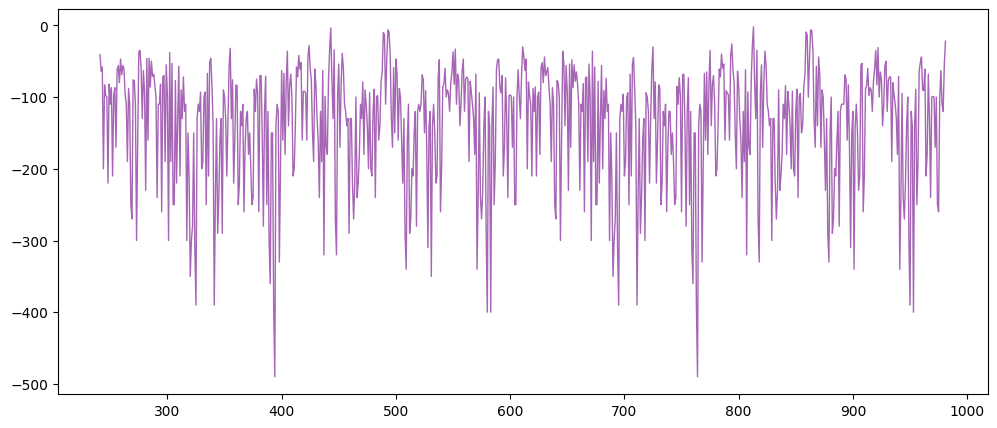

In [60]:
plt.figure(figsize=(12, 5))

profile_3g45 = os.path.join(modelling_dir, '3G45.profile')
df = pd.read_csv(profile_3g45, sep='\s+', comment='#', header=None)
residues = df[0] + 240
dope = df[df.columns[-1]]
plt.plot(residues, dope,
         color="#A665B5",
         linewidth=1,
         label='3G45 (template)')

<>:43: SyntaxWarning: invalid escape sequence '\s'
<>:43: SyntaxWarning: invalid escape sequence '\s'
C:\Users\vitor\AppData\Local\Temp\ipykernel_16492\1255708841.py:43: SyntaxWarning: invalid escape sequence '\s'
  df = pd.read_csv(profile_path, sep='\s+', comment='#', header=None)


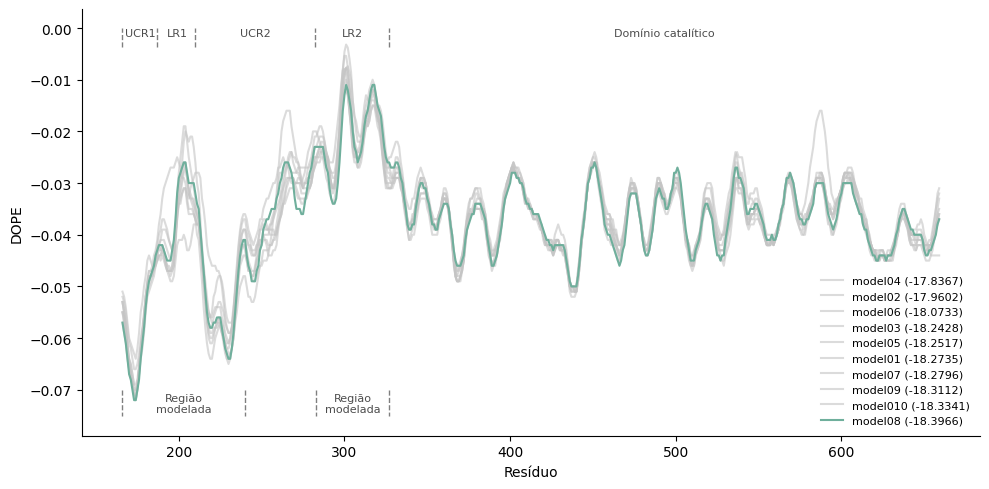

In [16]:
import matplotlib.pyplot as plt
import pandas as pd
import glob
import os
import re

#modelling_dir = '/home/gbiuser/Documents/vitoria/usp-masters/data/structure_prediction/homology_modelling/'
profiles_with_sum = []
profile_files = sorted(glob.glob(os.path.join(modelling_dir, 'model0*.profile')))
for profile_path in profile_files:
    total_sum = None
    with open(profile_path, 'r') as f:
        for line in f:
            match = re.search(r'The sum of all numbers in the file:\s+([-\d.]+)', line)
            if match:
                total_sum = float(match.group(1))
                break
    
    profiles_with_sum.append((profile_path, total_sum))

# ordenar do menor DOPE para o maior
profiles_with_sum.sort(key=lambda x: x[1], reverse=True)

plt.figure(figsize=(10, 5))

cinza = "#c4c4c4"
colors = [
    cinza,
    cinza,
    cinza,
    cinza,
    cinza,
    cinza,
    cinza,
    cinza,
    cinza,  
    '#6FAF9C'        
]

all_dope = []
for i, (profile_path, total_sum) in enumerate(profiles_with_sum):
    name = os.path.basename(profile_path).replace('.profile', '')
    df = pd.read_csv(profile_path, sep='\s+', comment='#', header=None)
    residues = df[0] + 165
    dope=df[df.columns[-1]]
    all_dope.extend(dope.tolist())
    label = f'{name} ({total_sum})'    

    if i == 9:
        alpha = 1
    else:
        alpha = 0.6

    plt.plot(residues, dope, label=label, color=colors[i], alpha=alpha)

# Scaling
margin = (max(all_dope) - min(all_dope)) * 0.1
plt.ylim(min(all_dope) - margin, max(all_dope) + margin)

plt.xlabel('Resíduo')
plt.ylabel('DOPE')
plt.title('')
plt.legend(fontsize=8,frameon=False)
ax = plt.gca()

y_top = 0 
y_cut = y_top - (y_top - min(all_dope)) * 0.05  # altura onde a linha para

ax.vlines(166, y_cut, y_top, linestyle='--', color='black', linewidth=1, alpha=0.5)
ax.vlines(187, y_cut, y_top, linestyle='--', color='black', linewidth=1, alpha=0.5)
ax.vlines(210, y_cut, y_top, linestyle='--', color='black', linewidth=1, alpha=0.5)
ax.vlines(282, y_cut, y_top, linestyle='--', color='black', linewidth=1, alpha=0.5)
ax.vlines(327, y_cut, y_top, linestyle='--', color='black', linewidth=1, alpha=0.5)

ax.vlines(166, -0.07, -0.075, linestyle='--', color='black', linewidth=1, alpha=0.5)
ax.vlines(240, -0.07, -0.075, linestyle='--', color='black', linewidth=1, alpha=0.5)
ax.vlines(283, -0.07, -0.075, linestyle='--', color='black', linewidth=1, alpha=0.5)
ax.vlines(327, -0.07, -0.075, linestyle='--', color='black', linewidth=1, alpha=0.5)

y_text = max(all_dope) - (max(all_dope) - min(all_dope)) 
ax.text((166+187)/2, y_text * 0.000001,
        'UCR1',
        ha='center',
        va='top',
        fontsize=8,
        alpha=0.7)

ax.text((188+210)/2, y_text* 0.000001,
        'LR1',
        ha='center',
        va='top',
        fontsize=8,
        alpha=0.7)

ax.text((211+282)/2, y_text* 0.000001,
        'UCR2',
        ha='center',
        va='top',
        fontsize=8,
        alpha=0.7)

ax.text((283+327)/2, y_text* 0.000001,
        'LR2',
        ha='center',
        va='top',
        fontsize=8,
        alpha=0.7)

ax.text((328+658)/2, y_text* 0.000001,
        'Domínio catalítico',
        ha='center',
        va='top',
        fontsize=8,
        alpha=0.7)

ax.text((166+240)/2, y_text *0.98,
        'Região\nmodelada',
        ha='center',
        va='top',
        fontsize=8,
        alpha=0.7)

ax.text((283+327)/2, y_text* 0.98,
        'Região\nmodelada',
        ha='center',
        va='top',
        fontsize=8,
        alpha=0.7)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(modelling_dir, 'dope_profiles.png'), dpi=150)
plt.show()

In [ ]:
# Rename model 8 (starts at 166)
def renumber_pdb(input_pdb, output_pdb, start=166):
    with open(input_pdb, 'r') as f:
        lines = f.readlines()
    
    current_resnum = None
    new_resnum = start - 1
    
    with open(output_pdb, 'w') as out:
        for line in lines:
            if line.startswith(('ATOM', 'HETATM')):
                res = line[22:26].strip()
                if res != current_resnum:
                    current_resnum = res
                    new_resnum += 1
                line = line[:22] + f'{new_resnum:4d}' + line[26:]
            out.write(line)

modelling_dir = '/home/gbiuser/Documents/vitoria/usp-masters/data/structure_prediction/modelling/'

In [8]:
from modeller import *
from modeller.automodel import *

class MyLoop(LoopModel):
    def select_loop_atoms(self):
        return Selection(
            self.residue_range('166:A', '187:A'), #ucr1
            self.residue_range('188:A', '210:A'), #lr1
            self.residue_range('211:A', '282:A'), #ucr2
            self.residue_range('283:A', '327:A'), #lr2
        )

env = Environ()
env.rand_seed = -1

a = MyLoop(env,
           alnfile='pde4d-pde4b.ali',
           knowns=('pde4d_swissmodel', 'pde4b_3g45'),
           sequence='pde4b_target',
           inimodel='pde4b_target.B99990008.pdb',
           assess_methods=assess.DOPE)

a.loop.starting_model = 1
a.loop.ending_model = 5
a.loop.md_level = refine.very_slow  # bom para loop

a.make()

openf___224_> Open           $(LIB)/restyp.lib
openf___224_> Open           ${MODINSTALL10v7}/modlib/restyp_cif.lib
openf___224_> Open           ${MODINSTALL10v7}/modlib/resgrp.lib
rdresgr_266_> Number of residue groups:        2
openf___224_> Open           ${MODINSTALL10v7}/modlib/sstruc.lib

Dynamically allocated memory at   amaxlibraries [B,KiB,MiB]:     31965859   31216.660    30.485

Dynamically allocated memory at   amaxlibraries [B,KiB,MiB]:     31966387   31217.176    30.486
openf___224_> Open           ${MODINSTALL10v7}/modlib/resdih.lib

Dynamically allocated memory at   amaxlibraries [B,KiB,MiB]:     32014987   31264.637    30.532
rdrdih__263_> Number of dihedral angle types         :        9
              Maximal number of dihedral angle optima:        3
              Dihedral angle names                   :  Alph Phi Psi Omeg chi1 chi2 chi3 chi4 chi5
openf___224_> Open           ${MODINSTALL10v7}/modlib/radii.lib

Dynamically allocated memory at   amaxlibraries [B,KiB,Mi

In [13]:
from modeller import *
from modeller.scripts import complete_pdb
import glob
import os

log.verbose()
env = Environ()
env.libs.topology.read(file='$(LIB)/top_heav.lib')
env.libs.parameters.read(file='$(LIB)/par.lib')

#modelling_dir = '/home/gbiuser/Documents/vitoria/usp-masters/data/structure_prediction/homology_modelling/'
modelling_dir = r'C:\Users\vitor\Documents\usp\usp-masters\data\structure_prediction\homology_modelling'
model_files = sorted(glob.glob(os.path.join(modelling_dir, '*BL*.pdb')))

openf___224_> Open           $(LIB)/restyp.lib
openf___224_> Open           ${MODINSTALL10v7}/modlib/restyp_cif.lib
openf___224_> Open           ${MODINSTALL10v7}/modlib/resgrp.lib
rdresgr_266_> Number of residue groups:        2
openf___224_> Open           ${MODINSTALL10v7}/modlib/sstruc.lib

Dynamically allocated memory at   amaxlibraries [B,KiB,MiB]:     39329364   38407.582    37.507

Dynamically allocated memory at   amaxlibraries [B,KiB,MiB]:     39329892   38408.098    37.508
openf___224_> Open           ${MODINSTALL10v7}/modlib/resdih.lib

Dynamically allocated memory at   amaxlibraries [B,KiB,MiB]:     39378492   38455.559    37.554
rdrdih__263_> Number of dihedral angle types         :        9
              Maximal number of dihedral angle optima:        3
              Dihedral angle names                   :  Alph Phi Psi Omeg chi1 chi2 chi3 chi4 chi5
openf___224_> Open           ${MODINSTALL10v7}/modlib/radii.lib

Dynamically allocated memory at   amaxlibraries [B,KiB,Mi

In [14]:
model_files

['C:\\Users\\vitor\\Documents\\usp\\usp-masters\\data\\structure_prediction\\homology_modelling\\pde4b_target.BL00010001.pdb',
 'C:\\Users\\vitor\\Documents\\usp\\usp-masters\\data\\structure_prediction\\homology_modelling\\pde4b_target.BL00020001.pdb',
 'C:\\Users\\vitor\\Documents\\usp\\usp-masters\\data\\structure_prediction\\homology_modelling\\pde4b_target.BL00030001.pdb',
 'C:\\Users\\vitor\\Documents\\usp\\usp-masters\\data\\structure_prediction\\homology_modelling\\pde4b_target.BL00040001.pdb',
 'C:\\Users\\vitor\\Documents\\usp\\usp-masters\\data\\structure_prediction\\homology_modelling\\pde4b_target.BL00050001.pdb']

In [18]:
for i, model_path in enumerate(model_files, start=1):
    profile_file = os.path.join(modelling_dir, f'submodel{i}.profile')
    
    print(f'calc DOPE model {i}: {os.path.basename(model_path)}')
    
    mdl = complete_pdb(env, model_path)
    s = Selection(mdl)
    s.assess_dope(output='ENERGY_PROFILE NO_REPORT', file=profile_file,
                  normalize_profile=True, smoothing_window=15)


calc DOPE model 1: pde4b_target.BL00010001.pdb
openf___224_> Open           C:\Users\vitor\Documents\usp\usp-masters\data\structure_prediction\homology_modelling\pde4b_target.BL00010001.pdb

Dynamically allocated memory at amaxcoordinates [B,KiB,MiB]:     38711713   37804.406    36.918

Dynamically allocated memory at    amaxsequence [B,KiB,MiB]:     38711789   37804.480    36.918

Dynamically allocated memory at amaxcoordinates [B,KiB,MiB]:     38711960   37804.648    36.919

Dynamically allocated memory at amaxcoordinates [B,KiB,MiB]:     38712810   37805.477    36.919

Dynamically allocated memory at amaxcoordinates [B,KiB,MiB]:     38714068   37806.707    36.921

Dynamically allocated memory at amaxcoordinates [B,KiB,MiB]:     38715972   37808.566    36.922

Dynamically allocated memory at    amaxsequence [B,KiB,MiB]:     38716012   37808.605    36.922

Dynamically allocated memory at amaxcoordinates [B,KiB,MiB]:     38716102   37808.695    36.923

Dynamically allocated memory at a

<>:38: SyntaxWarning: invalid escape sequence '\s'
<>:38: SyntaxWarning: invalid escape sequence '\s'
C:\Users\vitor\AppData\Local\Temp\ipykernel_16492\3711632222.py:38: SyntaxWarning: invalid escape sequence '\s'
  df = pd.read_csv(profile_path, sep='\s+', comment='#', header=None)


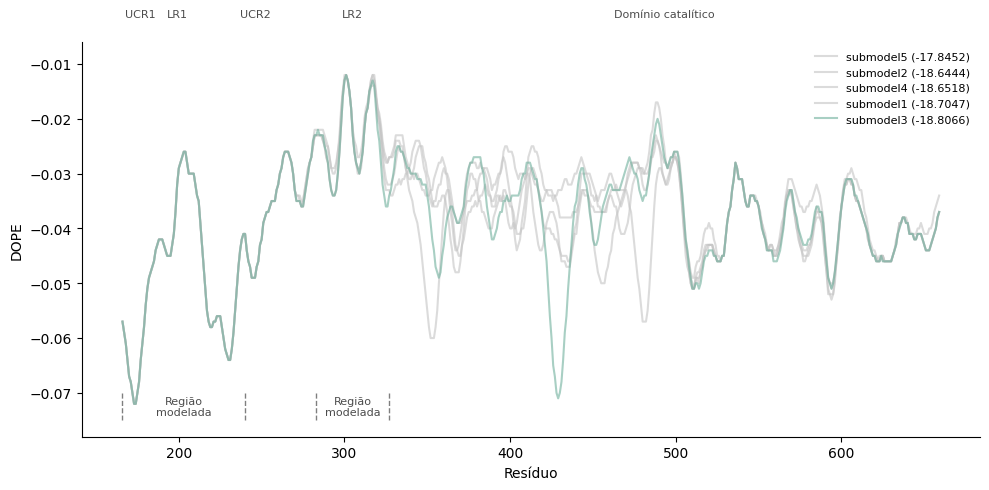

In [20]:
import matplotlib.pyplot as plt
import pandas as pd
import glob
import os
import re

#modelling_dir = '/home/gbiuser/Documents/vitoria/usp-masters/data/structure_prediction/homology_modelling/'
profiles_with_sum = []
profile_files = sorted(glob.glob(os.path.join(modelling_dir, 'submodel*.profile')))
for profile_path in profile_files:
    total_sum = None
    with open(profile_path, 'r') as f:
        for line in f:
            match = re.search(r'The sum of all numbers in the file:\s+([-\d.]+)', line)
            if match:
                total_sum = float(match.group(1))
                break
    
    profiles_with_sum.append((profile_path, total_sum))

# ordenar do menor DOPE para o maior
profiles_with_sum.sort(key=lambda x: x[1], reverse=True)

plt.figure(figsize=(10, 5))

cinza = "#c4c4c4"
colors = [
    cinza,
    cinza,
    cinza,
    cinza,
    '#6FAF9C'        
]

all_dope = []
for i, (profile_path, total_sum) in enumerate(profiles_with_sum):
    name = os.path.basename(profile_path).replace('.profile', '')
    df = pd.read_csv(profile_path, sep='\s+', comment='#', header=None)
    residues = df[0] + 165
    dope=df[df.columns[-1]]
    all_dope.extend(dope.tolist())
    label = f'{name} ({total_sum})'    

    if i == 9:
        alpha = 1
    else:
        alpha = 0.6

    plt.plot(residues, dope, label=label, color=colors[i], alpha=alpha)

# Scaling
margin = (max(all_dope) - min(all_dope)) * 0.1
plt.ylim(min(all_dope) - margin, max(all_dope) + margin)

plt.xlabel('Resíduo')
plt.ylabel('DOPE')
plt.title('')
plt.legend(fontsize=8,frameon=False)
ax = plt.gca()

y_top = 0 
y_cut = y_top - (y_top - min(all_dope)) * 0.05  # altura onde a linha para

ax.vlines(166, y_cut, y_top, linestyle='--', color='black', linewidth=1, alpha=0.5)
ax.vlines(187, y_cut, y_top, linestyle='--', color='black', linewidth=1, alpha=0.5)
ax.vlines(210, y_cut, y_top, linestyle='--', color='black', linewidth=1, alpha=0.5)
ax.vlines(282, y_cut, y_top, linestyle='--', color='black', linewidth=1, alpha=0.5)
ax.vlines(327, y_cut, y_top, linestyle='--', color='black', linewidth=1, alpha=0.5)

ax.vlines(166, -0.07, -0.075, linestyle='--', color='black', linewidth=1, alpha=0.5)
ax.vlines(240, -0.07, -0.075, linestyle='--', color='black', linewidth=1, alpha=0.5)
ax.vlines(283, -0.07, -0.075, linestyle='--', color='black', linewidth=1, alpha=0.5)
ax.vlines(327, -0.07, -0.075, linestyle='--', color='black', linewidth=1, alpha=0.5)

y_text = max(all_dope) - (max(all_dope) - min(all_dope)) 
ax.text((166+187)/2, y_text * 0.000001,
        'UCR1',
        ha='center',
        va='top',
        fontsize=8,
        alpha=0.7)

ax.text((188+210)/2, y_text* 0.000001,
        'LR1',
        ha='center',
        va='top',
        fontsize=8,
        alpha=0.7)

ax.text((211+282)/2, y_text* 0.000001,
        'UCR2',
        ha='center',
        va='top',
        fontsize=8,
        alpha=0.7)

ax.text((283+327)/2, y_text* 0.000001,
        'LR2',
        ha='center',
        va='top',
        fontsize=8,
        alpha=0.7)

ax.text((328+658)/2, y_text* 0.000001,
        'Domínio catalítico',
        ha='center',
        va='top',
        fontsize=8,
        alpha=0.7)

ax.text((166+240)/2, y_text *0.98,
        'Região\nmodelada',
        ha='center',
        va='top',
        fontsize=8,
        alpha=0.7)

ax.text((283+327)/2, y_text* 0.98,
        'Região\nmodelada',
        ha='center',
        va='top',
        fontsize=8,
        alpha=0.7)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(modelling_dir, 'dope_profiles.png'), dpi=150)
plt.show()

In [ ]:
# Constrain UCR1 (166-187)
renumber_pdb(
    input_pdb=modelling_dir + 'pde4b_target.B99990008.pdb',   # ajuste pro nome real do arquivo
    output_pdb=modelling_dir + '../model8.pdb',
    start=166
)

